In [1]:
import pandas as pd
import json
import os
import matplotlib as mpl
from matplotlib import pyplot as plt
import requests
from io import StringIO as sio
from matplotlib.patches import Patch
import matplotlib.ticker as ticker
import re
import itertools
import networkx as nx
import sys
import baltic as bt
from itertools import combinations
from collections import defaultdict
import random

In [2]:
# tree_95_path = "prepped/summary-95.nwk"
# tree_75_path = "prepped/summary-75.nwk"
# original_path = "prepped/backbone.nwk"

# paths = [tree_95_path, tree_75_path, original_path]

In [3]:
# for tree in paths:
    
#     print(tree)

#     with open(tree, 'r') as file:
#         modified = file.read()

#     # removing commas between segments
#     def repl(match):
#         cleaned = re.sub(r",\s*", "-", match.group(1))
#         return f"rea={cleaned}"

#     modified = re.sub(r'rea=([^]\)]+)', repl, modified)

#     # removing quotation marks around node names
#     modified = re.sub(r"'(TS_NODE_\d+)'", r'\1', modified)

#     with open(f"{tree}", "w") as output_file:
#         output_file.write(modified.strip())

In [4]:
tree_95 = bt.loadNewick("prepped/summary-95.nwk", absoluteTime= False)
tree_75 = bt.loadNewick("prepped/summary-75.nwk", absoluteTime= False)
original = bt.loadNewick("prepped/backbone.nwk", absoluteTime= False)

In [5]:
tree_dict = {"tree_95": tree_95, "tree_75": tree_75, "original": original}

In [6]:
reassortment_count = {}
gene_segment_counts = {name: {} for name in tree_dict.keys()}
num_segment_counts = {name: {} for name in tree_dict.keys()}
leaf_list = {name: [] for name in tree_dict.keys()}
nodes = {}
leaves = {}

# dictionary for segment co-occurrences
segment_pair_counts = {name: defaultdict(lambda: defaultdict(int)) for name in tree_dict.keys()}

gene_segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']

for name, tree in tree_dict.items():
    
    leaf = []
    node_count = 0
    leaf_count = 0
    count = 0
    tree_segment_counts = {segment: 0 for segment in gene_segments}
    num_segments_involved = {i: 0 for i in range(1, 8)}
    
    for k in tree.Objects:
        if k.traits.get('is_reassorted'):
            
            raw_segments = k.traits["rea"]
            is_uncertain = all([g_str.startswith('_') for g_str in raw_segments.split('-')])
            
            lst = [seg.split("(")[0].lstrip('_') for seg in raw_segments.split("-")]
            num_segments_involved[len(lst)] += 1
            count += 0.5 if is_uncertain else 1
            
            for seg in lst:
                tree_segment_counts[seg] += 0.5 if seg.startswith('_') else 1
                
            if k.is_node():
                node_count += 0.5 if is_uncertain else 1
            else:
                leaf_count += 0.5 if is_uncertain else 1
                leaf.append(k.name)
            
            # counting segment pairs (combinations of 2)
            if len(lst) > 1:
                for seg1, seg2 in combinations(lst, 2):
                    # increment both directions for easy access
                    segment_pair_counts[name][seg1][seg2] += 1
                    segment_pair_counts[name][seg2][seg1] += 1
    
    leaf_list[name] = leaf
    reassortment_count[name] = count
    nodes[name] = node_count
    leaves[name] = leaf_count
    gene_segment_counts[name] = tree_segment_counts
    num_segment_counts[name] = num_segments_involved

In [7]:
num_segment_counts

{'tree_95': {1: 1062, 2: 286, 3: 88, 4: 44, 5: 26, 6: 16, 7: 3},
 'tree_75': {1: 1273, 2: 357, 3: 116, 4: 50, 5: 33, 6: 19, 7: 5},
 'original': {1: 1152, 2: 645, 3: 336, 4: 227, 5: 147, 6: 63, 7: 25}}

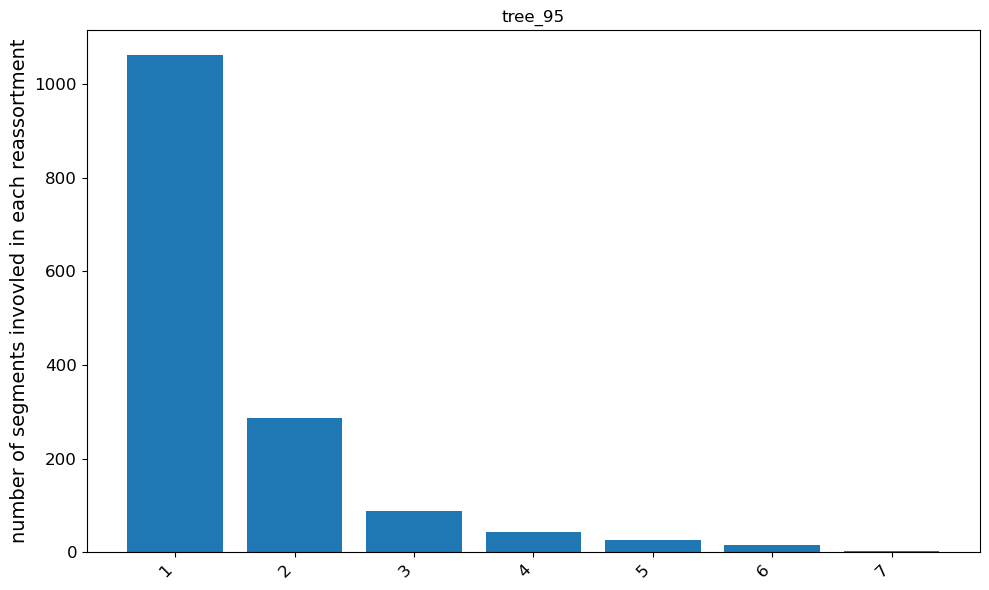

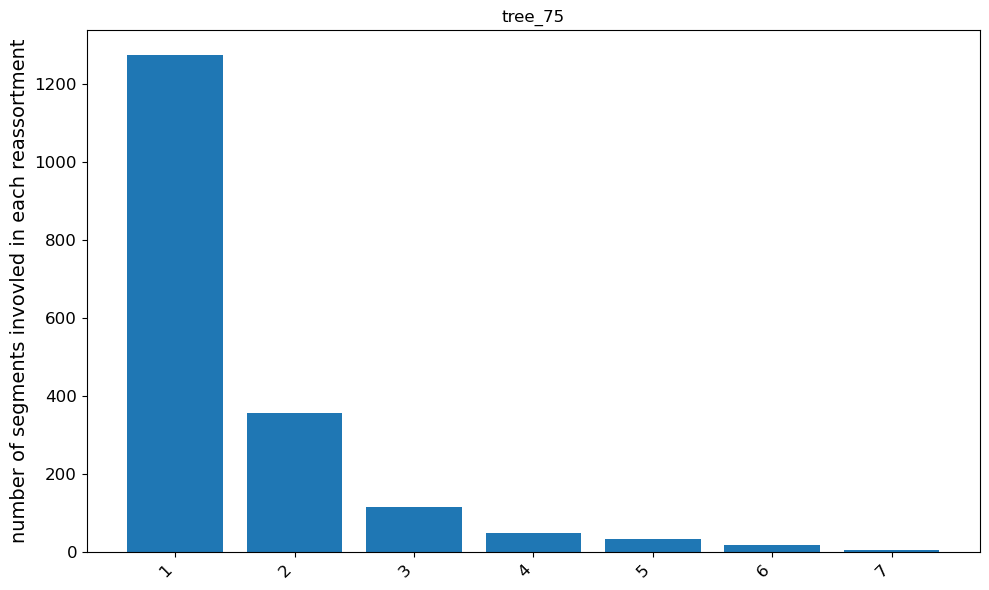

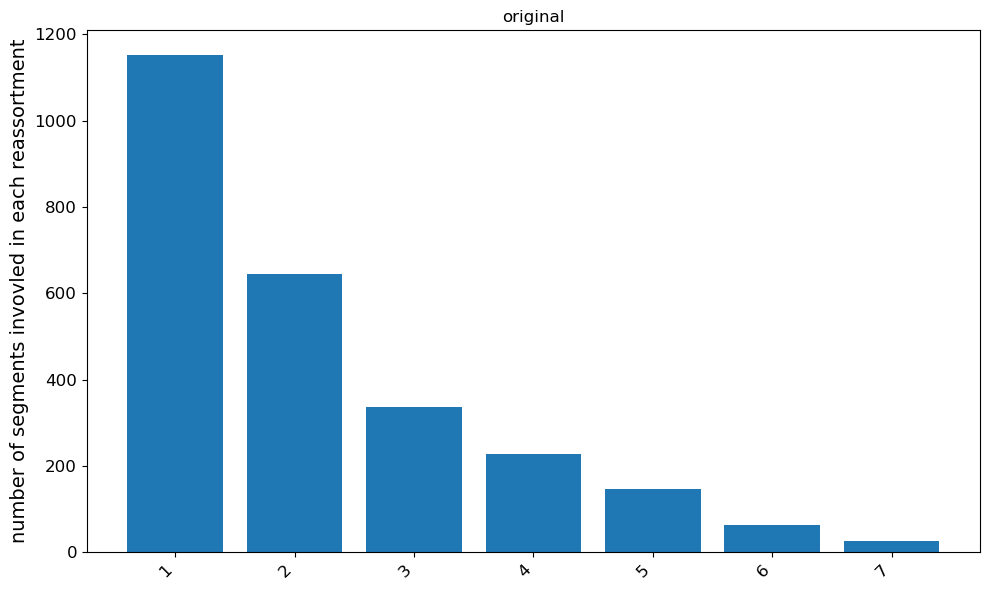

In [8]:
for name in tree_dict.keys():
    
    counts = []
    labels = []

    for num_segments, count in num_segment_counts[name].items():
        counts.append(count)
        labels.append(num_segments)

    plt.figure(figsize=(10, 6))
    plt.bar(labels, counts)
    
    
    plt.title(f"{name}")
    plt.ylabel('number of segments invovled in each reassortment', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()

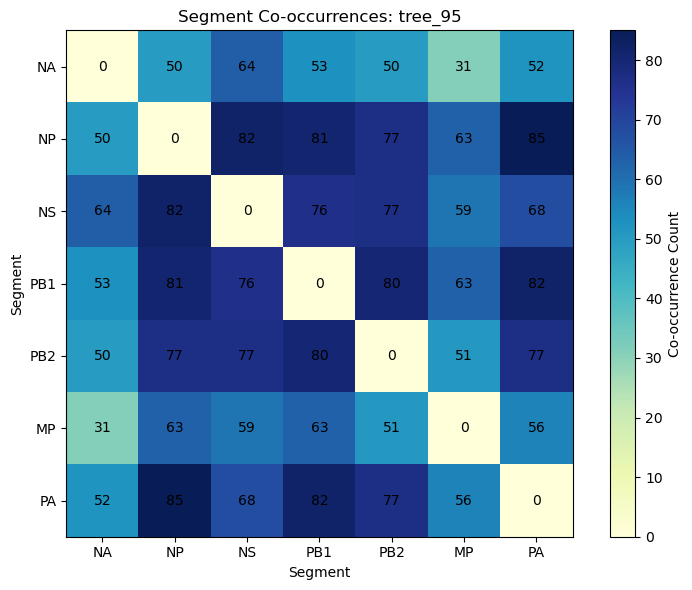

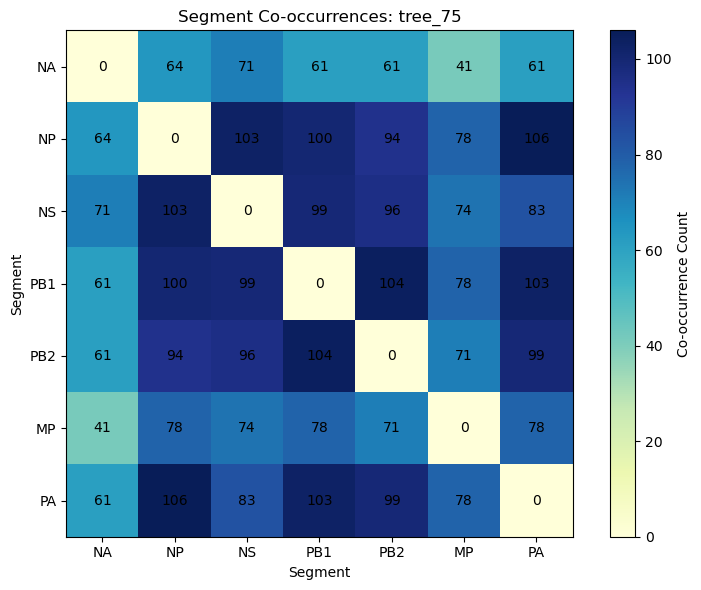

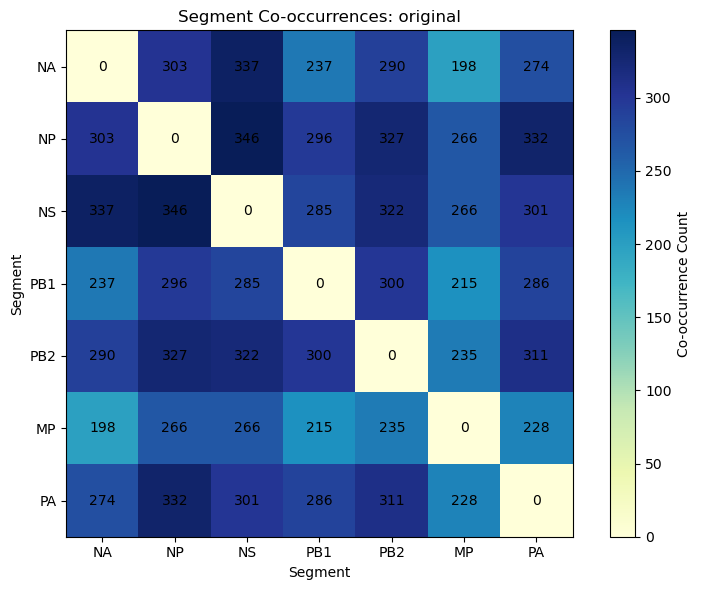

In [9]:
import matplotlib.pyplot as plt
import numpy as np

gene_segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']

for name in tree_dict.keys():
    # Create a co-occurrence matrix
    co_matrix = np.zeros((len(gene_segments), len(gene_segments)), dtype=int)
    
    for i, seg1 in enumerate(gene_segments):
        for j, seg2 in enumerate(gene_segments):
            co_matrix[i, j] = segment_pair_counts[name][seg1].get(seg2, 0)
    
    plt.figure(figsize=(8,6))
    im = plt.imshow(co_matrix, cmap='YlGnBu')
    plt.colorbar(im, label='Co-occurrence Count')
    
    # Set axis labels
    plt.xticks(ticks=np.arange(len(gene_segments)), labels=gene_segments)
    plt.yticks(ticks=np.arange(len(gene_segments)), labels=gene_segments)
    
    # Annotate the cells with counts
    for i in range(len(gene_segments)):
        for j in range(len(gene_segments)):
            plt.text(j, i, co_matrix[i, j], ha='center', va='center', color='black')
    
    plt.title(f"Segment Co-occurrences: {name}")
    plt.xlabel("Segment")
    plt.ylabel("Segment")
    plt.tight_layout()
    plt.show()


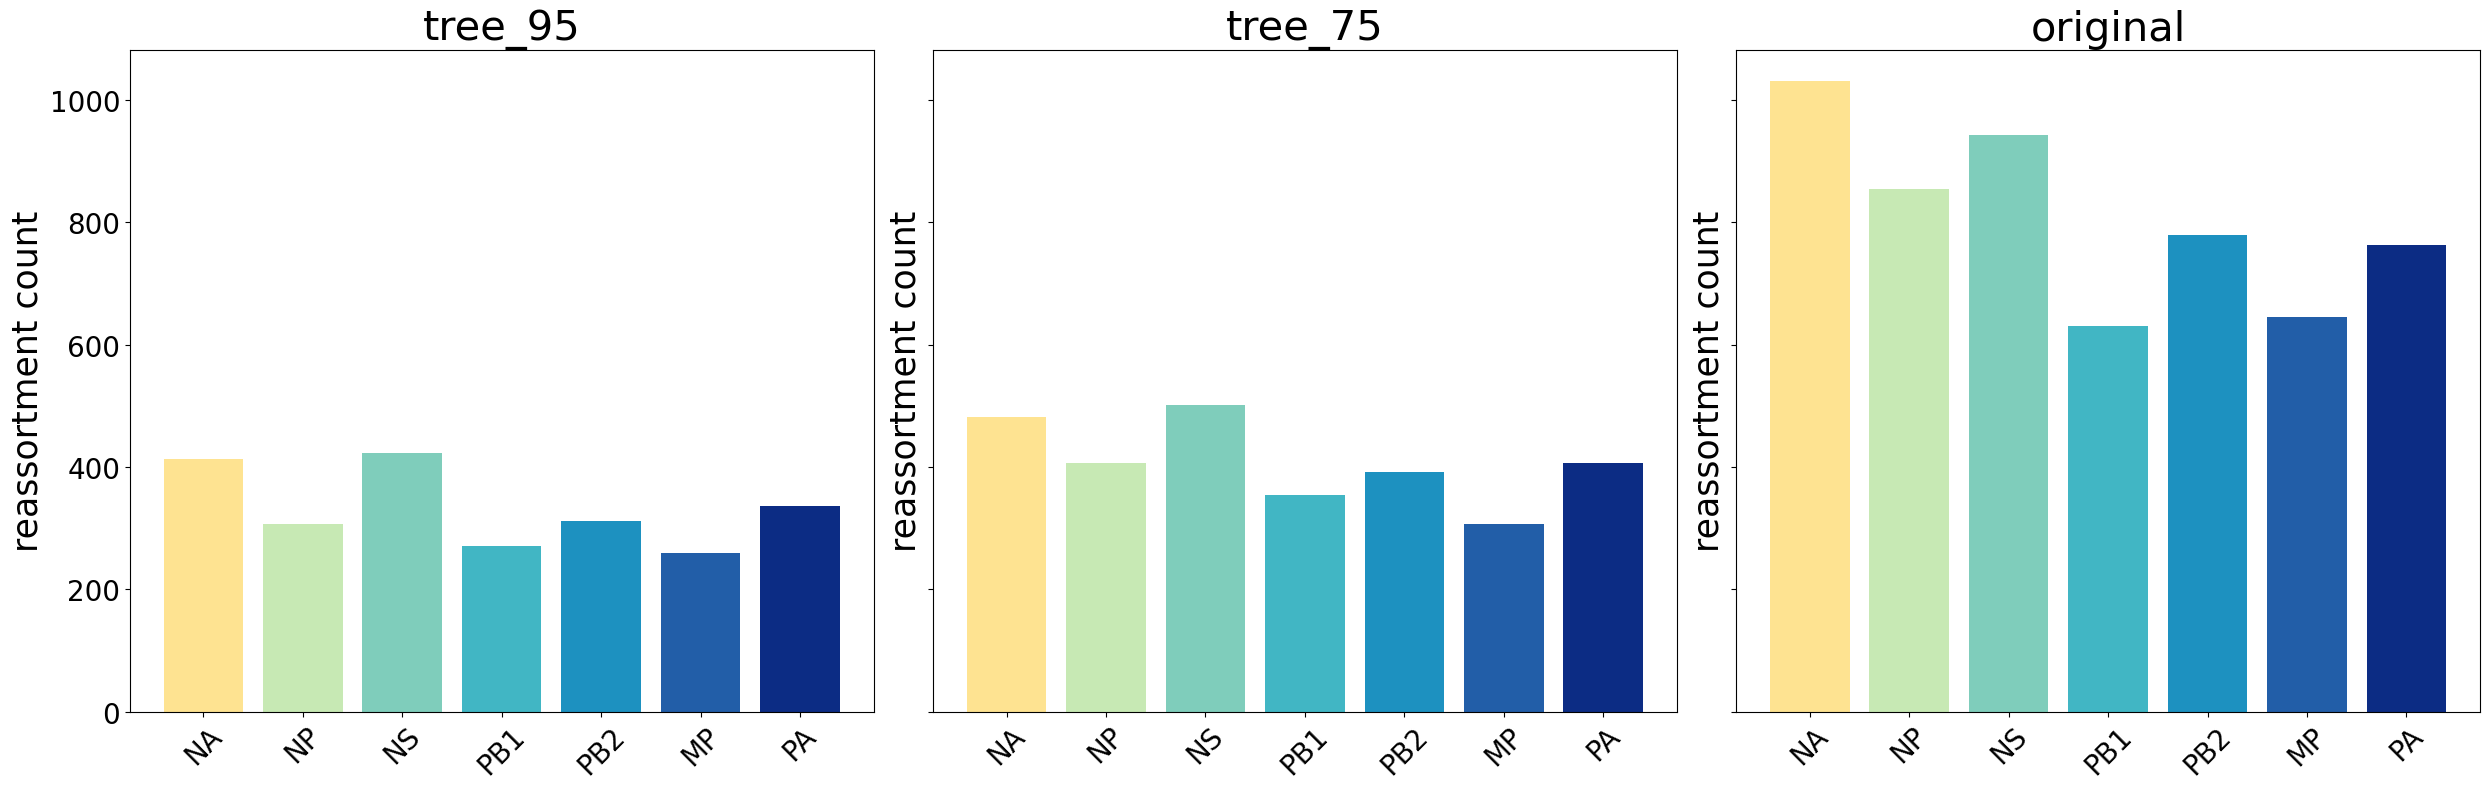

In [10]:
import matplotlib.pyplot as plt
import numpy as np

genes = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']  # consistent order
colors = ['#fee391', '#c7e9b4', '#7fcdbb', '#41b6c4', '#1d91c0', '#225ea8', '#0c2c84']

trees = list(tree_dict.keys())  # ["tree_95", "tree_75", "original"]

fig, axes = plt.subplots(nrows=1, ncols=len(trees), figsize=(25, 8), sharey=True)

if len(trees) == 1:
    axes = [axes]  # make iterable if only one subplot

for idx, tree_name in enumerate(trees):
    ax = axes[idx]
    
    # Values for this tree: one bar per gene
    values = [gene_segment_counts[tree_name][gene] for gene in genes]
    x = np.arange(len(genes))
    
    ax.bar(x, values, color=colors, width=0.8)
    
    ax.set_title(tree_name, fontsize=30)
    ax.set_xticks(x)
    ax.set_xticklabels(genes, rotation=45, fontsize=20)
    ax.set_ylabel('reassortment count', fontsize=25)
    ax.tick_params(axis='y', labelsize=20)

plt.tight_layout()
plt.show()


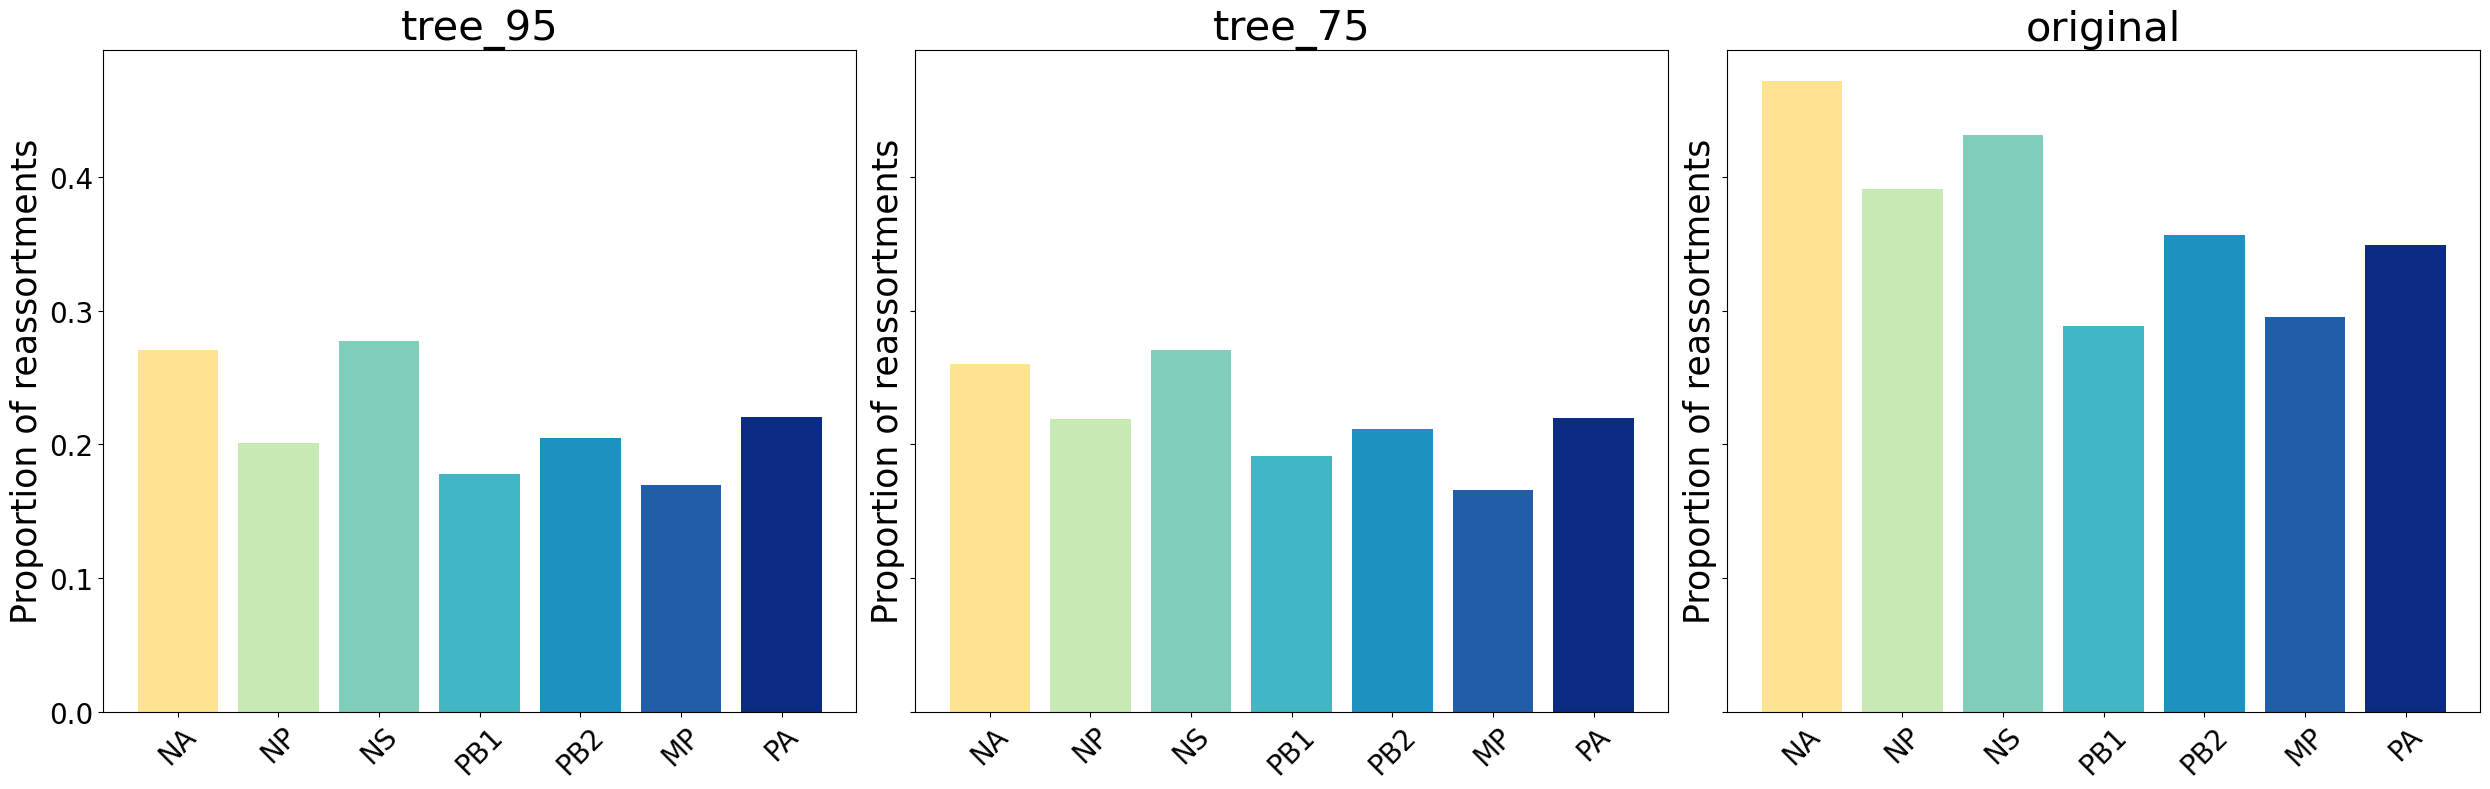

In [11]:
import matplotlib.pyplot as plt
import numpy as np

genes = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']  # consistent order
colors = ['#fee391', '#c7e9b4', '#7fcdbb', '#41b6c4', '#1d91c0', '#225ea8', '#0c2c84']

trees = list(tree_dict.keys())  # ["tree_95", "tree_75", "original"]

fig, axes = plt.subplots(nrows=1, ncols=len(trees), figsize=(25, 8), sharey=True)

if len(trees) == 1:
    axes = [axes]  # make iterable if only one subplot

for idx, tree_name in enumerate(trees):
    ax = axes[idx]
    
    total_reassort = reassortment_count[tree_name]  # total reassortments for this tree
    # Values for this tree: proportion per gene
    values = [gene_segment_counts[tree_name][gene] / total_reassort for gene in genes]
    
    x = np.arange(len(genes))
    
    ax.bar(x, values, color=colors, width=0.8)
    
    ax.set_title(tree_name, fontsize=30)
    ax.set_xticks(x)
    ax.set_xticklabels(genes, rotation=45, fontsize=20)
    ax.set_ylabel('Proportion of reassortments', fontsize=25)
    ax.tick_params(axis='y', labelsize=20)

plt.tight_layout()
plt.show()


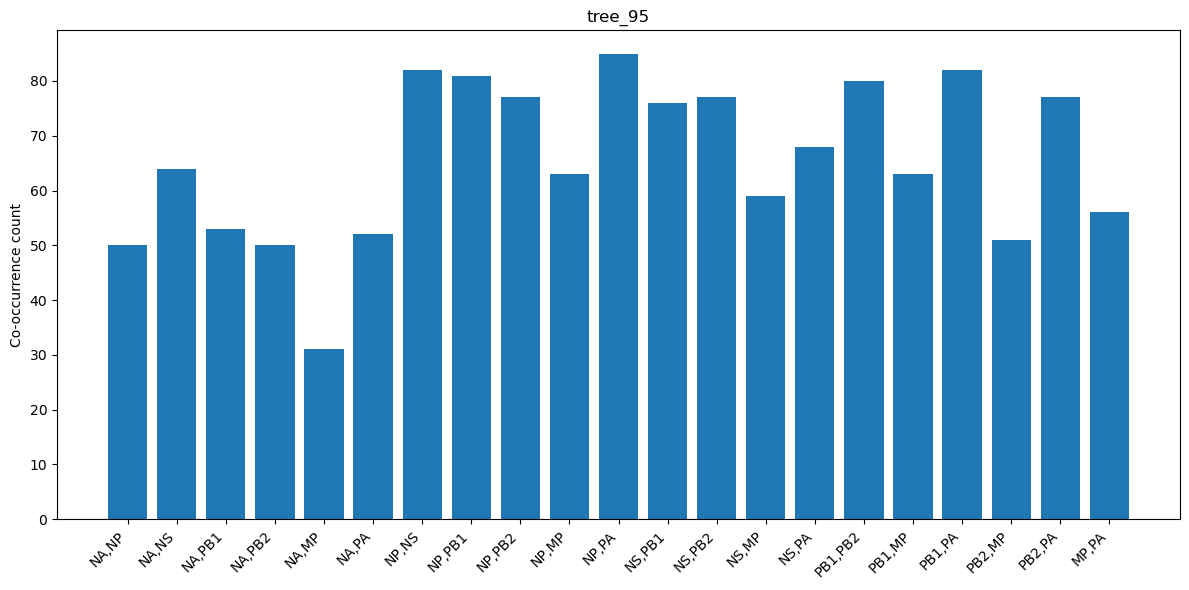

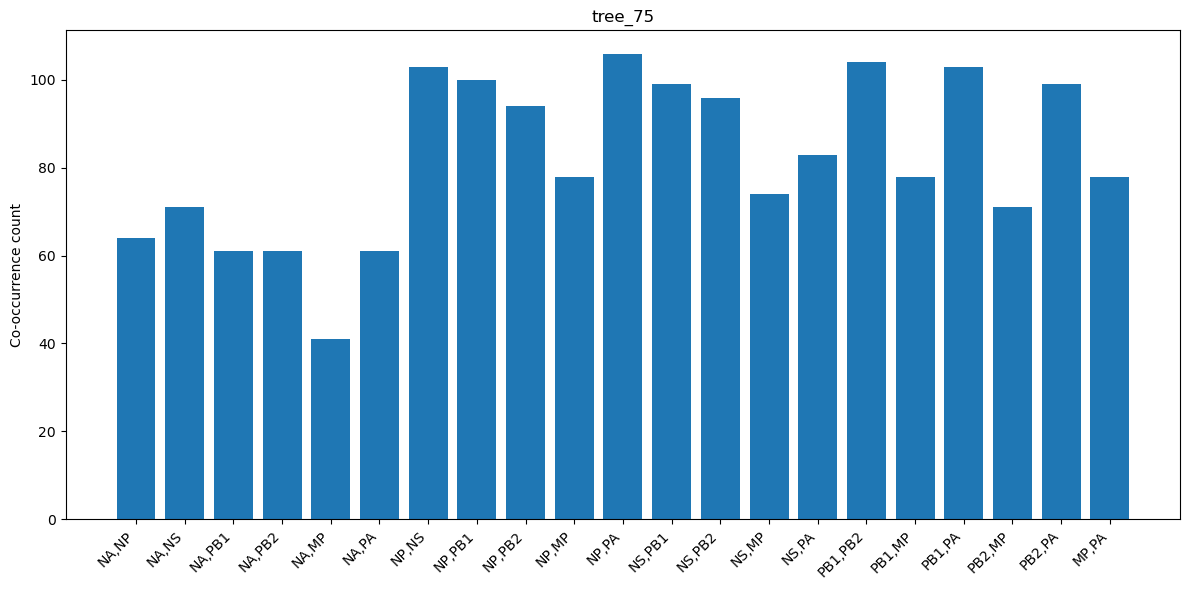

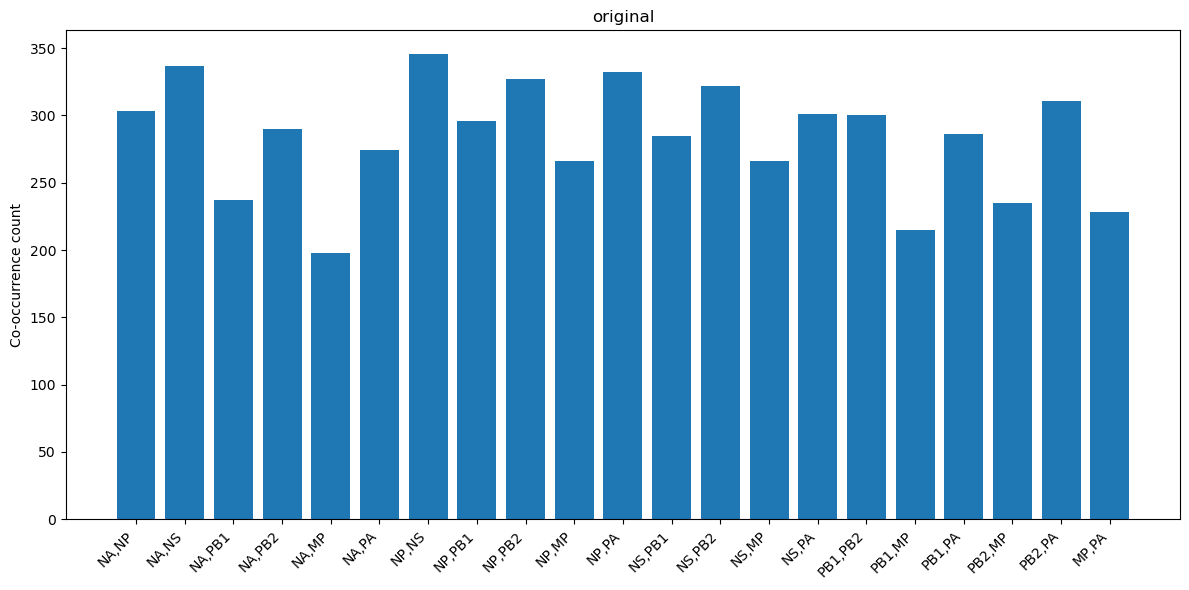

In [12]:
import matplotlib.pyplot as plt
import itertools

gene_segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']

for name in tree_dict.keys():
    pairs = []
    counts = []

    # Flatten the segment_pair_counts into pairs and counts
    for i, seg1 in enumerate(gene_segments):
        for j, seg2 in enumerate(gene_segments):
            if i < j:  # only count each pair once
                count = segment_pair_counts[name][seg1].get(seg2, 0)
                if count > 0:
                    pairs.append(f"{seg1},{seg2}")
                    counts.append(count)
    
    # Create bar plot
    plt.figure(figsize=(12,6))
    plt.bar(pairs, counts)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Co-occurrence count")
    plt.title(name)
    plt.tight_layout()
    plt.show()


In [13]:
import itertools

gene_segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']

for name in tree_dict.keys():
    missing_pairs = []

    # Loop over all unique pairs
    for seg1, seg2 in itertools.combinations(gene_segments, 2):
        count = segment_pair_counts[name][seg1].get(seg2, 0)
        if count == 0:
            missing_pairs.append(f"{seg1},{seg2}")
    
    print(f"Tree: {name}")
    print("Missing segment pairs:", missing_pairs)
    print()


Tree: tree_95
Missing segment pairs: []

Tree: tree_75
Missing segment pairs: []

Tree: original
Missing segment pairs: []



In [14]:
def simulate_single_run(segment_counts, gene_segments, seed=None):
    """
    Create one simulation run for a single tree.
    Returns: {'rea1': [seg,...], 'rea2': [...], ...}
    segment_counts: dict mapping n_segments -> n_events (e.g. {1:1062, 2:286, ...})
    gene_segments: list of segment names (e.g. ['NA','NP',...])
    """
    random.seed(seed)
    events = {}
    rea_idx = 1
    for n_segments in sorted(segment_counts.keys()):
        n_events = int(segment_counts[n_segments])
        for _ in range(n_events):
            # WITHOUT replacement:
            chosen = random.sample(gene_segments, k=n_segments)

            events[f"rea{rea_idx}"] = chosen
            rea_idx += 1
    return events

def simulate_null_distributions(segment_counts, gene_segments, n_sims=10, seed=None):
    """
    Produce n_sims simulations.
    Returns: {'sim1': {...}, 'sim2': {...}, ...}
    If seed is provided, each sim gets a deterministically different seed.
    """
    sims = {}
    base_seed = seed
    for i in range(1, n_sims + 1):
        sim_seed = None if base_seed is None else base_seed + i
        sims[f"sim{i}"] = simulate_single_run(segment_counts, gene_segments, seed=sim_seed)
    return sims

num_segment_counts = {
    'tree_95': {1: 1062, 2: 286, 3: 88, 4: 44, 5: 26, 6: 16, 7: 3},
    'tree_75': {1: 1273, 2: 357, 3: 116, 4: 50, 5: 33, 6: 19, 7: 5},
    'original': {1: 1152, 2: 645, 3: 336, 4: 227, 5: 147, 6: 63, 7: 25}
}
gene_segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']

# Simulate 10 runs for tree_95 (start small)

for name in tree_dict.keys():
    sims_tree = simulate_null_distributions(num_segment_counts[name], gene_segments, n_sims=1000, seed=51)

    # quick sanity checks
    print("Number of sims:", len(sims_tree))
    print(f"Events in sims_{name}:", len(sims_tree['sim1']))


Number of sims: 1000
Events in sims_tree_95: 1525
Number of sims: 1000
Events in sims_tree_75: 1853
Number of sims: 1000
Events in sims_original: 2595


In [15]:
num_segment_counts

{'tree_95': {1: 1062, 2: 286, 3: 88, 4: 44, 5: 26, 6: 16, 7: 3},
 'tree_75': {1: 1273, 2: 357, 3: 116, 4: 50, 5: 33, 6: 19, 7: 5},
 'original': {1: 1152, 2: 645, 3: 336, 4: 227, 5: 147, 6: 63, 7: 25}}

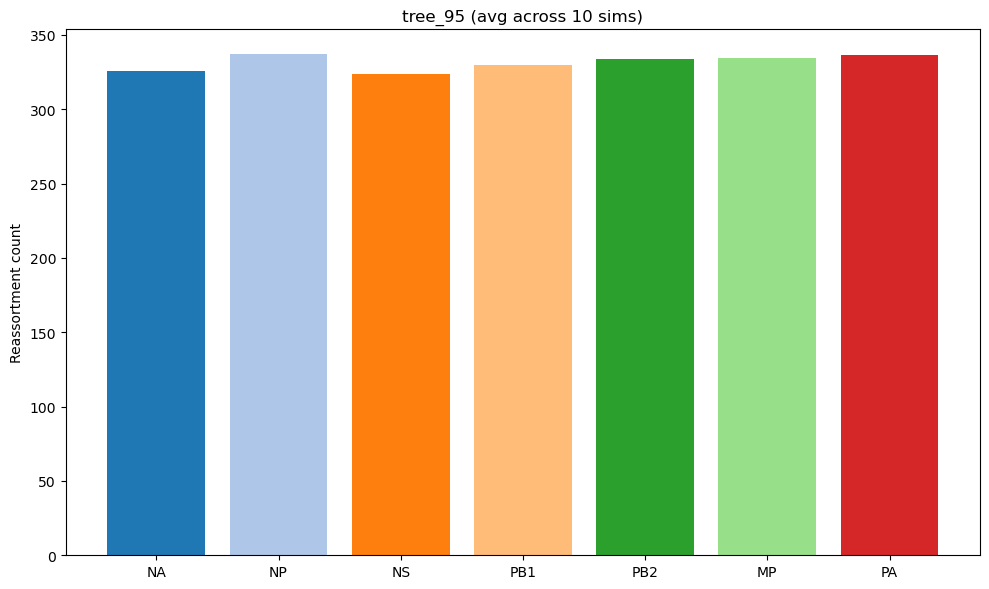

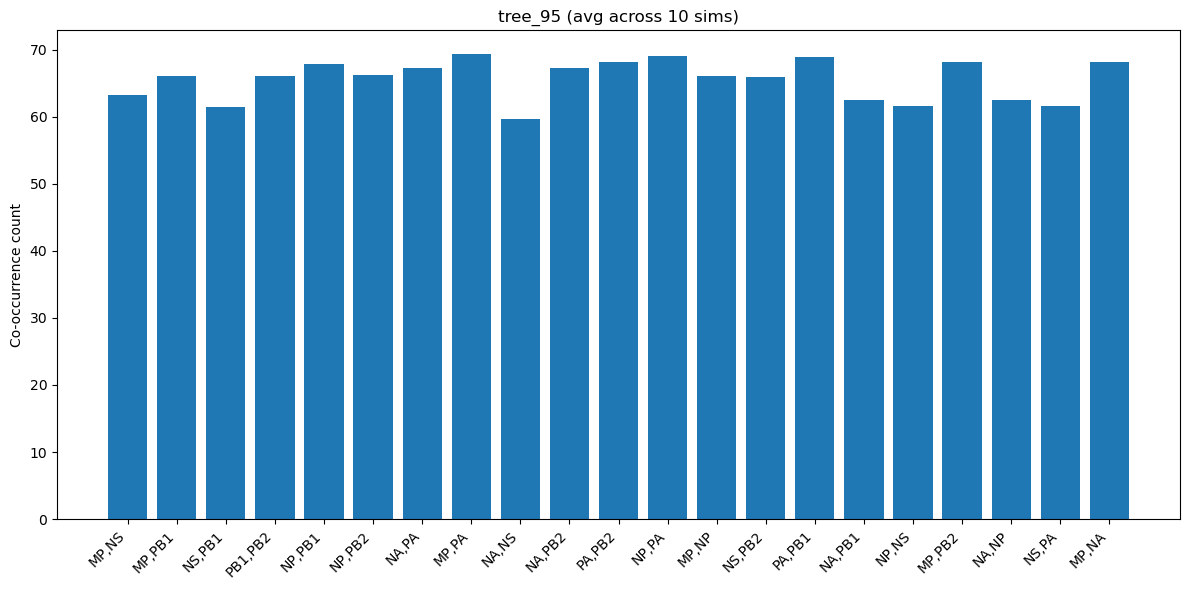

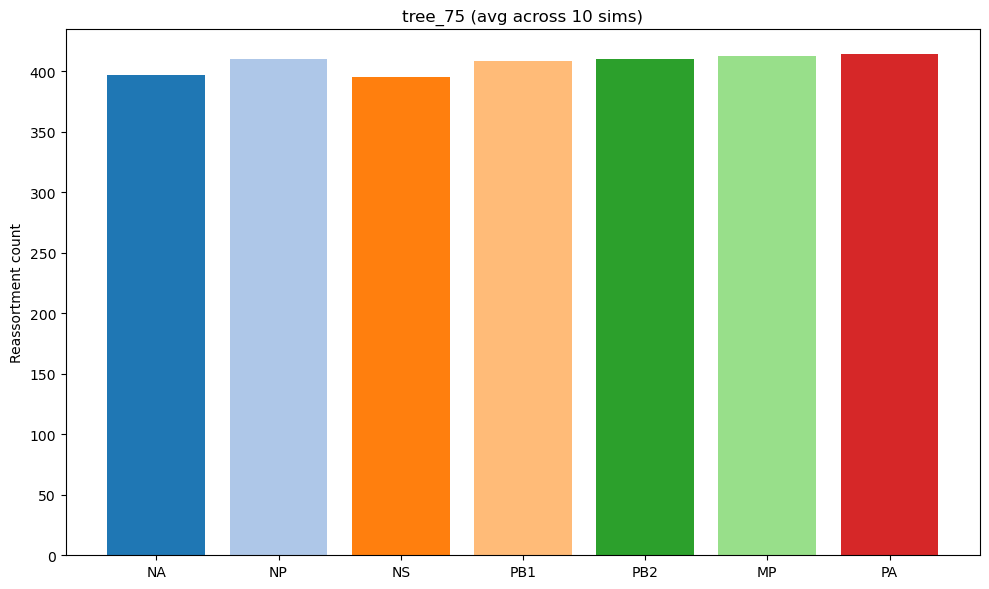

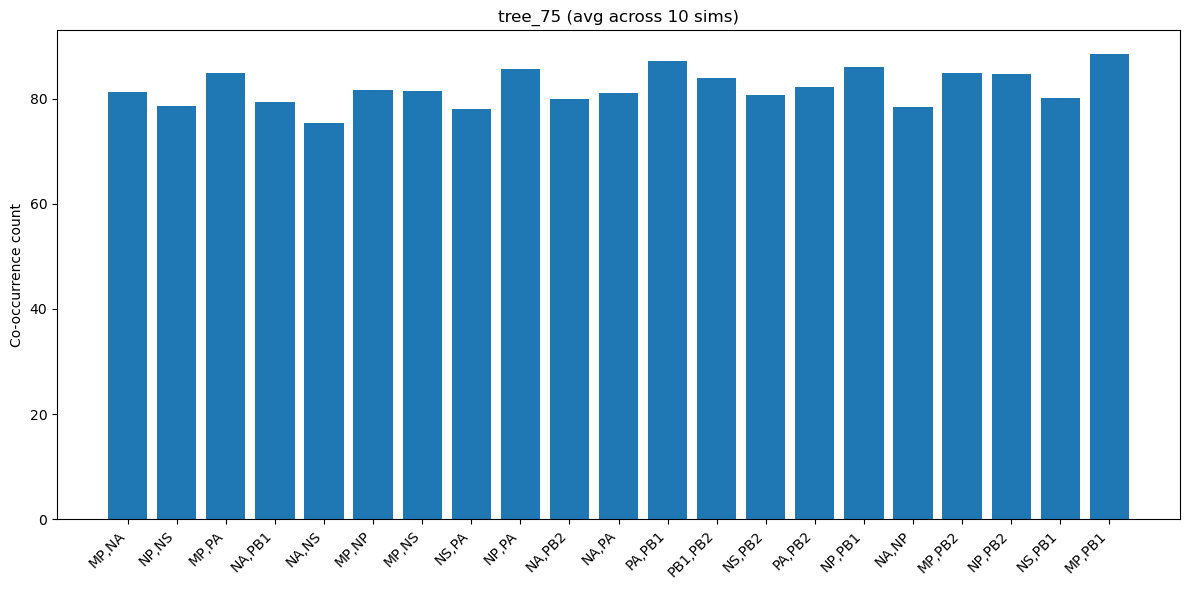

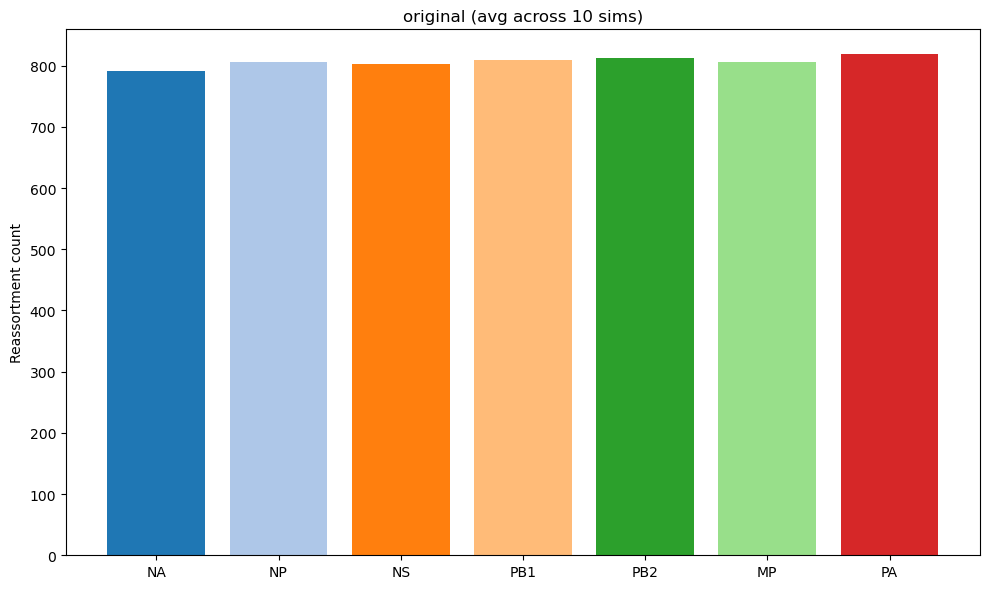

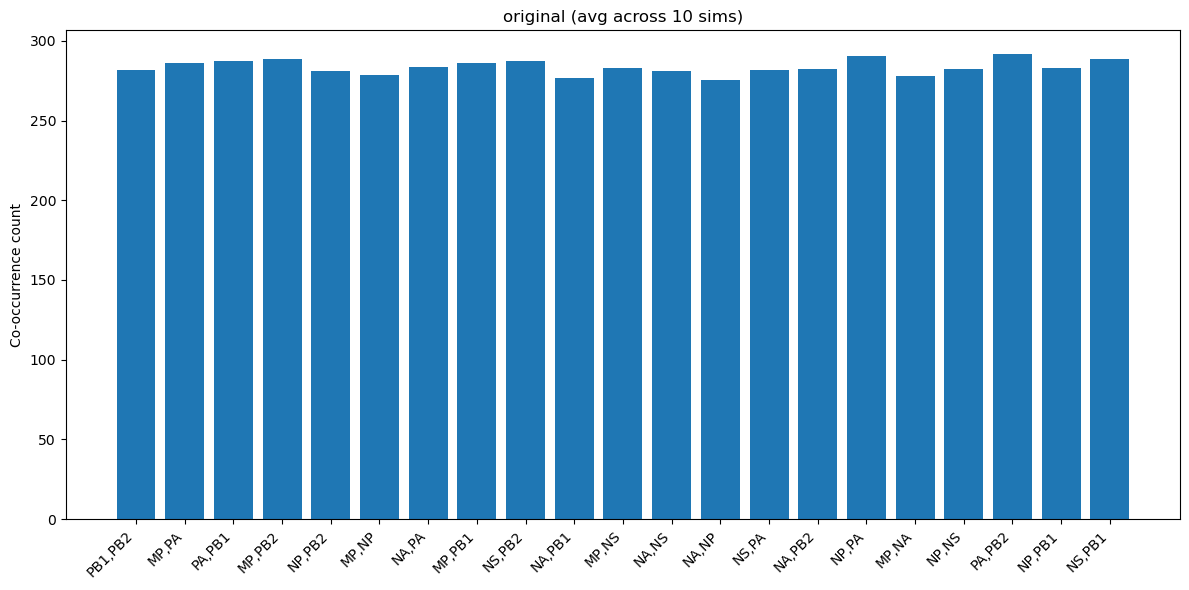

In [25]:
import itertools
import matplotlib.pyplot as plt
from collections import Counter


def count_segment_occurrences(events):
    """
    Count how many times each segment occurs in a set of reassortment events.
    """
    segment_counts = Counter()
    for segs in events.values():
        for seg in segs:
            segment_counts[seg] += 1
    return segment_counts

def count_cooccurrences(events):
    """
    Count pairwise co-occurrences in simulated events.
    events: dict of {rea#: [seg1, seg2, ...]}
    Returns: Counter with pairs as keys and counts as values.
    """
    pair_counts = Counter()
    for segs in events.values():
        if len(segs) > 1:  # only events with >1 segments
            # all unique pairs in the event
            for a, b in itertools.combinations(sorted(segs), 2):
                pair_counts[(a, b)] += 1
    return pair_counts


def plot_segment_counts(segment_counts, title):
    """
    Plot a bar chart of segment occurrences.
    """
    
    colors = ['#fee391', '#c7e9b4', '#7fcdbb', '#41b6c4', '#1d91c0', '#225ea8', '#0c2c84']
    
    segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']
    counts = [segment_counts.get(seg, 0) for seg in segments]

    plt.figure(figsize=(10,6))
    plt.bar(segments, counts, color=plt.cm.tab20.colors[:len(segments)])
    plt.ylabel("Reassortment count")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_cooccurrences(pair_counts, title):
    """
    Plot a bar chart of co-occurrence counts.
    """
    pairs = ['{},{}'.format(a, b) for (a, b) in pair_counts.keys()]
    counts = list(pair_counts.values())

    plt.figure(figsize=(12,6))
    plt.bar(pairs, counts)
    plt.ylabel("Co-occurrence count")
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    
'''
num_segment_counts.items: 

{'tree_95': {1: 1062, 2: 286, 3: 88, 4: 44, 5: 26, 6: 16, 7: 3},
 'tree_75': {1: 1273, 2: 357, 3: 116, 4: 50, 5: 33, 6: 19, 7: 5},
 'original': {1: 1152, 2: 645, 3: 336, 4: 227, 5: 147, 6: 63, 7: 25}}
 
'''

# 3 trees, N simulations each
# it should be completely uniform as you up the n_sims
for name, seg_counts in num_segment_counts.items(): # loop over each tree's reassortment by segment # distribution
    
    sims_tree = simulate_null_distributions(seg_counts, gene_segments, n_sims=10, seed=51) # simulate the null distribution using the real data

    segment_sum = Counter()
    pair_sum = Counter()
    n_sims = len(sims_tree)

    # loop once over sims
    for sim_events in sims_tree.values():
        segment_sum.update(count_segment_occurrences(sim_events))
        pair_sum.update(count_cooccurrences(sim_events)) # should be 21 pairs

    # average across sims, building new dictionaries to use
    avg_segment_counts = {seg: count / n_sims for seg, count in segment_sum.items()}
    avg_pair_counts = {pair: count / n_sims for pair, count in pair_sum.items()}

    plot_segment_counts(avg_segment_counts, title=f"{name} (avg across {n_sims} sims)")
    plot_cooccurrences(avg_pair_counts, title=f"{name} (avg across {n_sims} sims)")

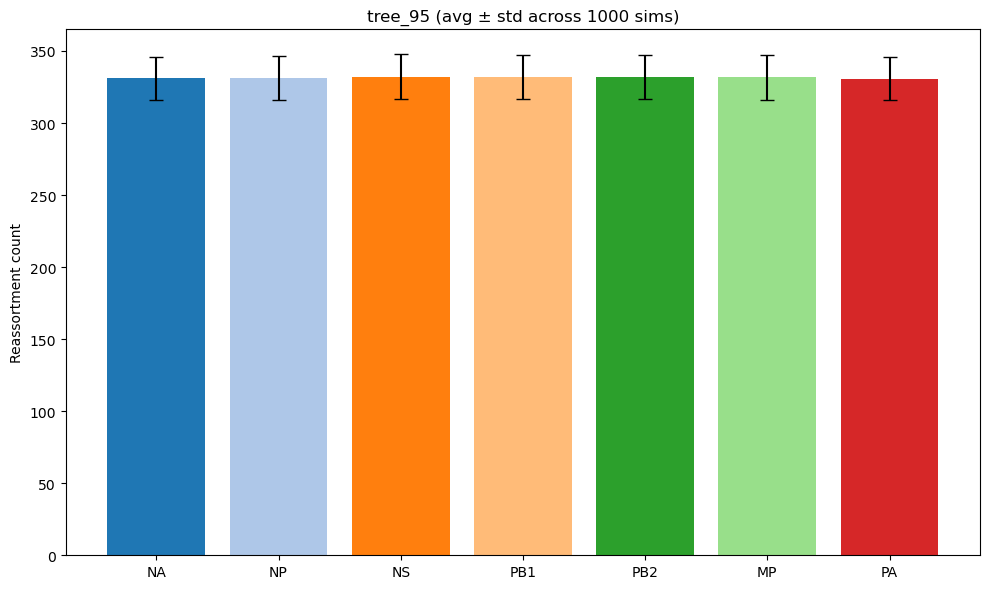

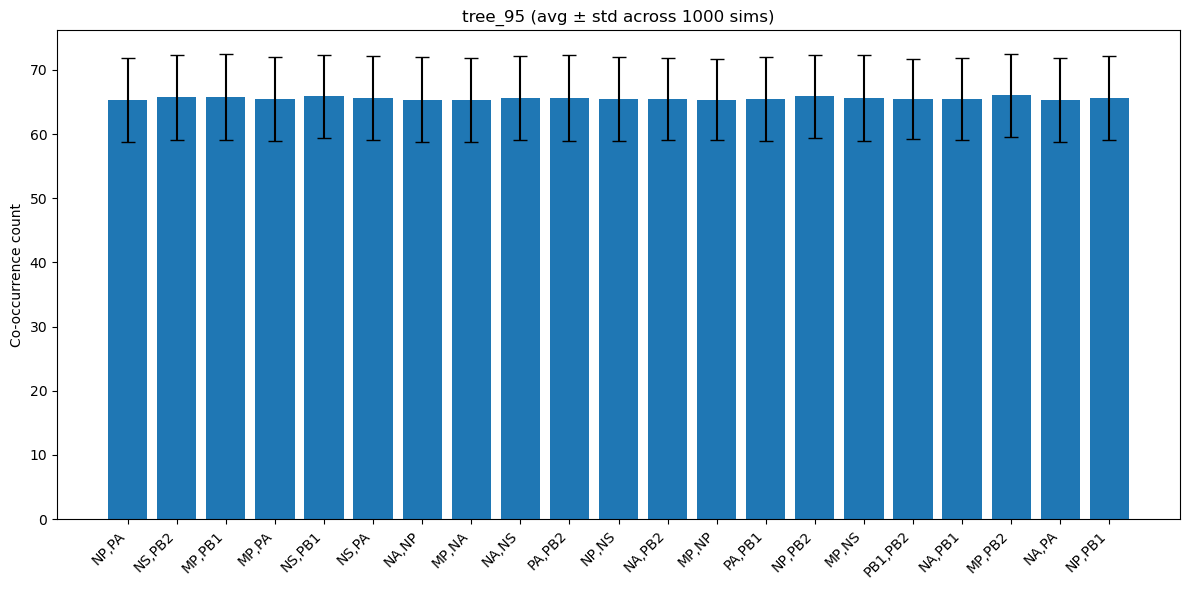

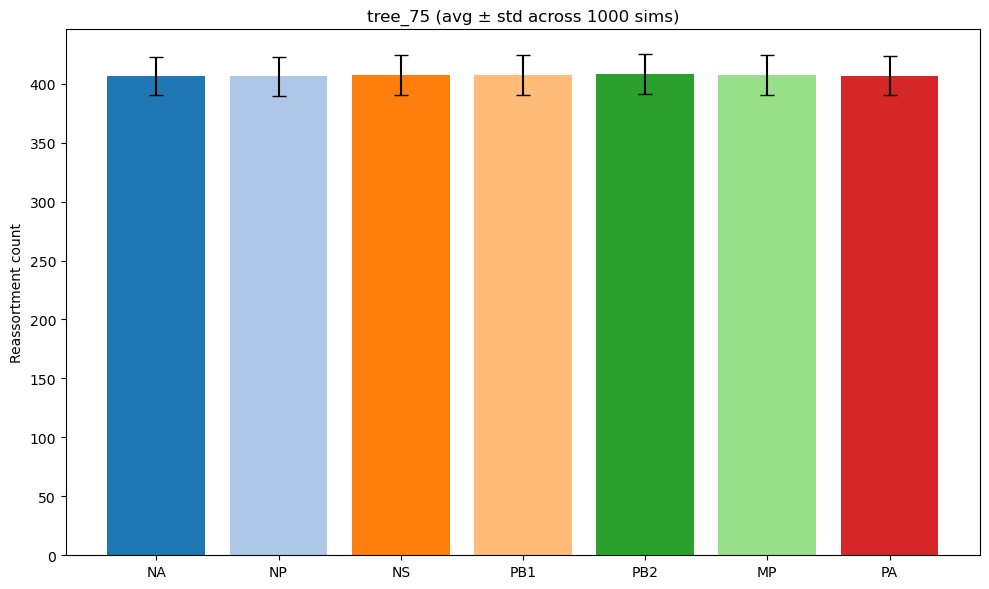

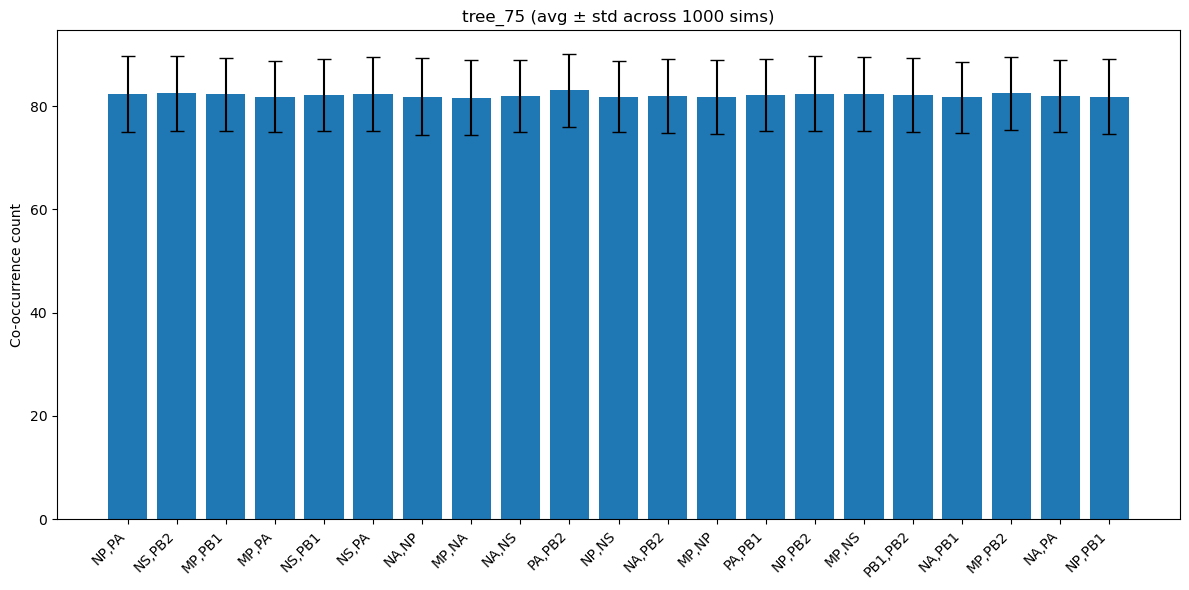

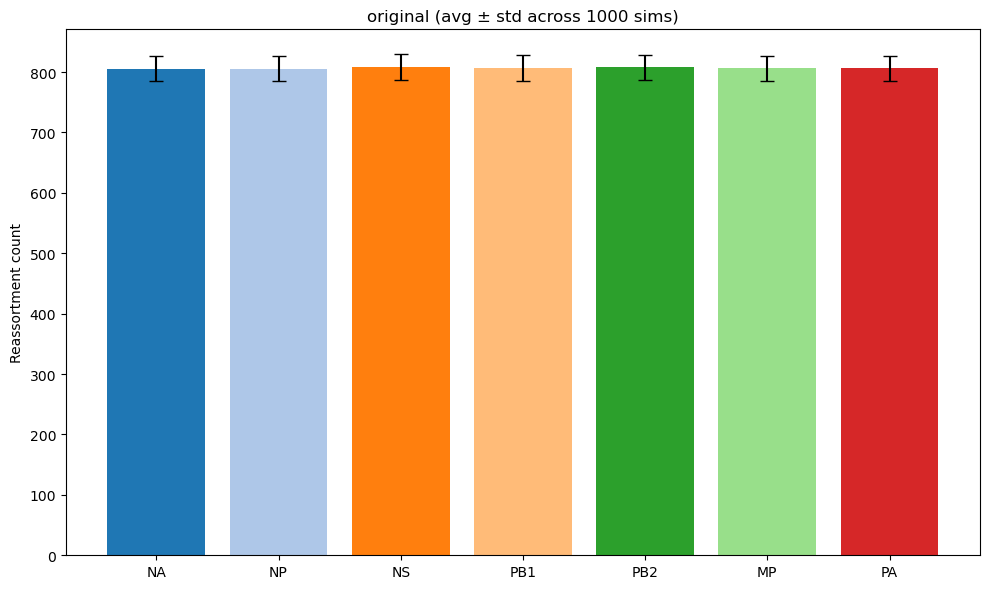

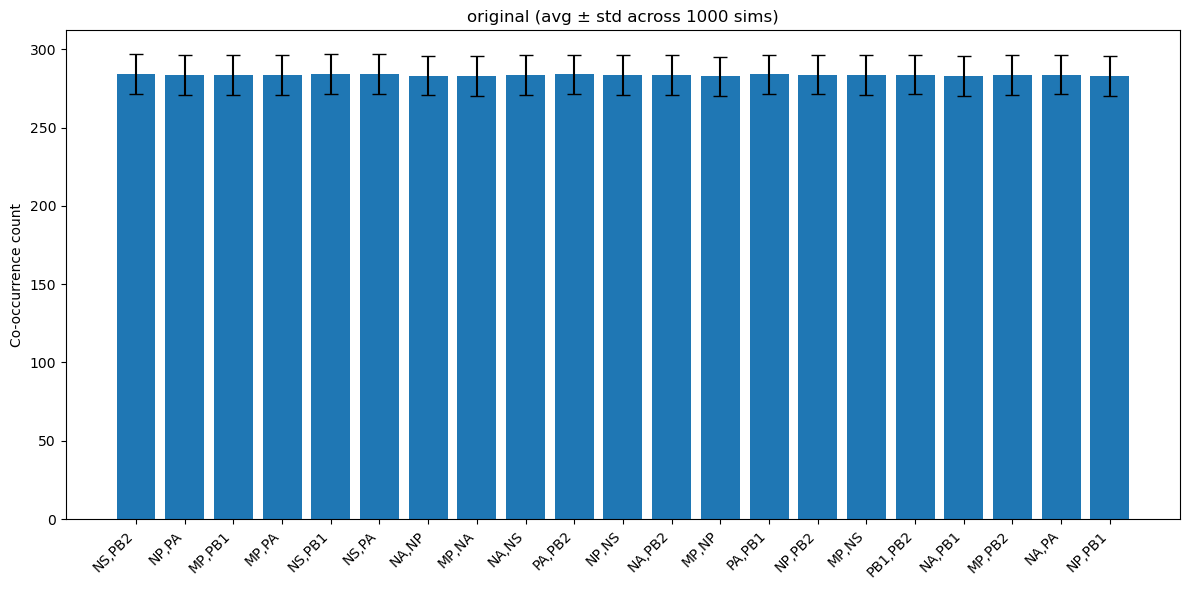

In [17]:
import numpy as np

def plot_segment_counts_with_error(segment_means, segment_stds, title):
    """
    Plot bar chart of average segment occurrences with std error bars.
    """
    segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']
    means = [segment_means.get(seg, 0) for seg in segments]
    errs = [segment_stds.get(seg, 0) for seg in segments]

    plt.figure(figsize=(10,6))
    plt.bar(segments, means, yerr=errs, capsize=5,
            color=plt.cm.tab20.colors[:len(segments)])
    plt.ylabel("Reassortment count")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_cooccurrences_with_error(pair_means, pair_stds, title):
    """
    Plot bar chart of average co-occurrences with std error bars.
    """
    pairs = ['{},{}'.format(a, b) for (a, b) in pair_means.keys()]
    means = list(pair_means.values())
    errs = [pair_stds.get(pair, 0) for pair in pair_means.keys()]

    plt.figure(figsize=(12,6))
    plt.bar(pairs, means, yerr=errs, capsize=5)
    plt.ylabel("Co-occurrence count")
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


# Loop over trees
for name, seg_counts in num_segment_counts.items():
    
    sims_tree = simulate_null_distributions(seg_counts, gene_segments, n_sims=1000, seed=51)

    # store per-sim results
    all_segment_counts = []
    all_pair_counts = []

    for sim_events in sims_tree.values():
        all_segment_counts.append(count_segment_occurrences(sim_events))
        all_pair_counts.append(count_cooccurrences(sim_events))

    # --- compute mean & std ---
    segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']

    segment_means = {seg: np.mean([sc.get(seg, 0) for sc in all_segment_counts])
                     for seg in segments}
    segment_stds  = {seg: np.std([sc.get(seg, 0) for sc in all_segment_counts])
                     for seg in segments}

    all_pairs = set().union(*[pc.keys() for pc in all_pair_counts])
    pair_means = {pair: np.mean([pc.get(pair, 0) for pc in all_pair_counts])
                  for pair in all_pairs}
    pair_stds  = {pair: np.std([pc.get(pair, 0) for pc in all_pair_counts])
                  for pair in all_pairs}

    plot_segment_counts_with_error(segment_means, segment_stds, 
                                   title=f"{name} (avg ± std across {len(sims_tree)} sims)")
    plot_cooccurrences_with_error(pair_means, pair_stds, 
                                  title=f"{name} (avg ± std across {len(sims_tree)} sims)")
